In [30]:
#dropping non relevant columns
df = df.drop(columns=["StockCode", "Description", "Country"])

In [28]:
df = df[~df["InvoiceNo"].astype(str).str.upper().str.startswith("C")]

In [29]:
# removing invalid transactions (invalid prices or quantities)
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

In [26]:
df = df.drop_duplicates()

In [27]:
# removing all the rows w/ missing customerID
df = df.dropna(subset=["CustomerID"])

In [3]:

import numpy as np

In [4]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt


In [25]:
file_path = '/Users/garimathapa/Downloads/Online Retail.xlsx'
df = pd.read_excel(file_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
%pip install openpyxl


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

In [9]:
%pip install openpyxl --break-system-packages

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [10]:
file_path = '/Users/garimathapa/Downloads/Online Retail.xlsx'
df = pd.read_excel(file_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [31]:
# TotalPrice — foundation for everything else
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# 1. Summary stats
df[["Quantity", "UnitPrice", "TotalPrice"]].describe()

,Quantity,UnitPrice,TotalPrice
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [32]:
# 2. Unique counts
print("Unique customers:", df["CustomerID"].nunique())   # ~4,338
print("Unique invoices:", df["InvoiceNo"].nunique())      # ~18,532
print("Total transactions (rows):", df.shape[0])          # ~392,692

Unique customers: 4338
Unique invoices: 18532
Total transactions (rows): 392692


In [33]:
# 3. Order value distribution (per invoice)
invoice_totals = df.groupby("InvoiceNo")["TotalPrice"].sum()
invoice_totals.describe()

count     18532.00000
mean        479.56016
std        1678.08258
min           0.38000
25%         157.34000
50%         302.57500
75%         469.57000
max      168469.60000
Name: TotalPrice, dtype: float64

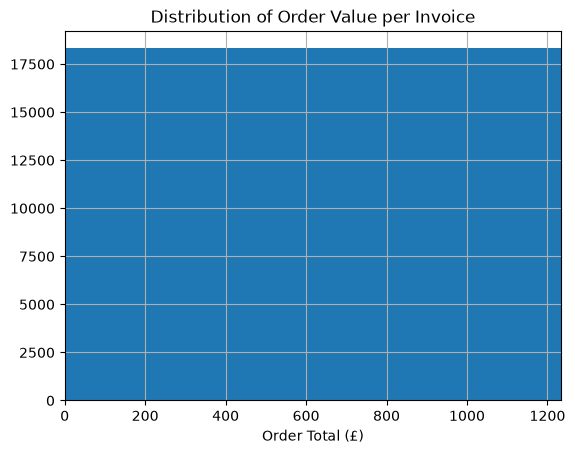

In [34]:
invoice_totals.hist(bins=50)
plt.xlim(0, invoice_totals.quantile(0.95))
plt.title("Distribution of Order Value per Invoice")
plt.xlabel("Order Total (£)")
plt.show()

In [35]:
# 4. Orders per customer (frequency)
customer_orders = df.groupby("CustomerID")["InvoiceNo"].nunique()
customer_orders.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

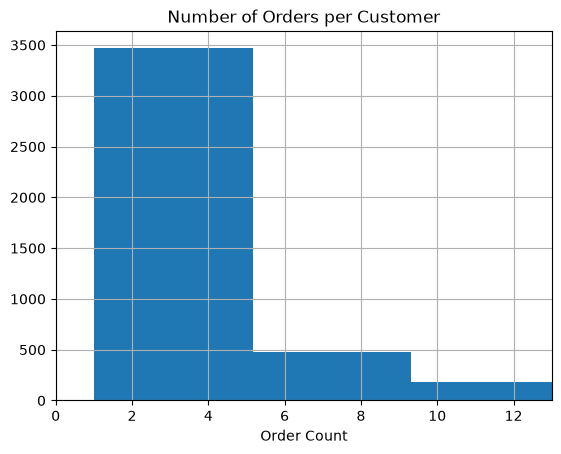

In [36]:
customer_orders.hist(bins=50)
plt.xlim(0, customer_orders.quantile(0.95))
plt.title("Number of Orders per Customer")
plt.xlabel("Order Count")
plt.show()

In [37]:
# 5. Outlier check — this dataset has a £168k max TotalPrice, worth flagging
print(df.sort_values("TotalPrice", ascending=False)[["InvoiceNo","Quantity","UnitPrice","TotalPrice"]].head(10))

       InvoiceNo  Quantity  UnitPrice  TotalPrice
540421    581483     80995       2.08   168469.60
61619     541431     74215       1.04    77183.60
222680    556444        60     649.50    38970.00
173382    551697         1    8142.75     8142.75
348325    567423      1412       5.06     7144.72
52711     540815      3114       2.10     6539.40
160546    550461      3114       2.10     6539.40
421601    573003      2400       2.08     4992.00
52709     540815      1930       2.55     4921.50
160542    550461      1930       2.40     4632.00


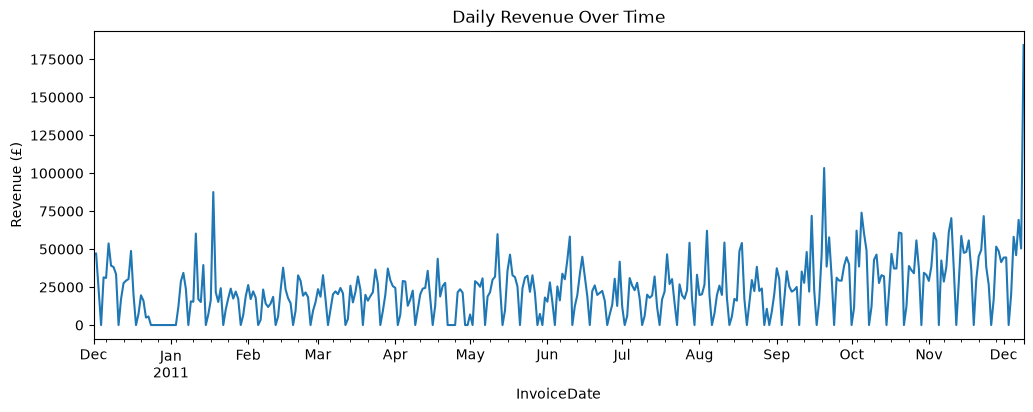

In [39]:
# 6. Revenue over time — your data spans Dec 2010 to Dec 2011
df.set_index("InvoiceDate")["TotalPrice"].resample("D").sum().plot(figsize=(12,4))
plt.title("Daily Revenue Over Time")
plt.ylabel("Revenue (£)")
plt.show()

In [40]:
# Extract useful time features
df["Hour"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Month"] = df["InvoiceDate"].dt.month_name()

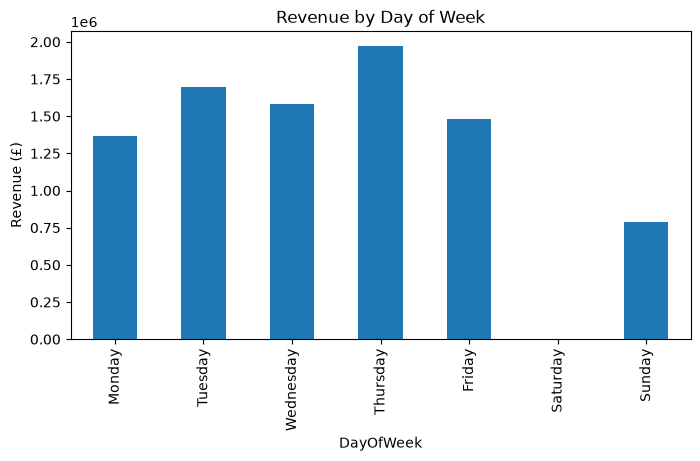

In [41]:
# 1. Revenue by day of week — are weekends slower for B2B-style wholesale?
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df.groupby("DayOfWeek")["TotalPrice"].sum().reindex(order).plot(kind="bar", figsize=(8,4))
plt.title("Revenue by Day of Week")
plt.ylabel("Revenue (£)")
plt.show()


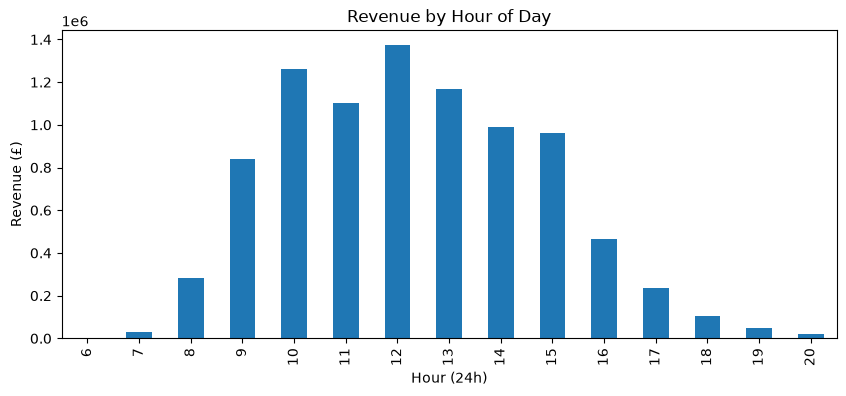

In [42]:
# 2. Revenue by hour of day — when do purchases happen?
df.groupby("Hour")["TotalPrice"].sum().plot(kind="bar", figsize=(10,4))
plt.title("Revenue by Hour of Day")
plt.xlabel("Hour (24h)")
plt.ylabel("Revenue (£)")
plt.show()

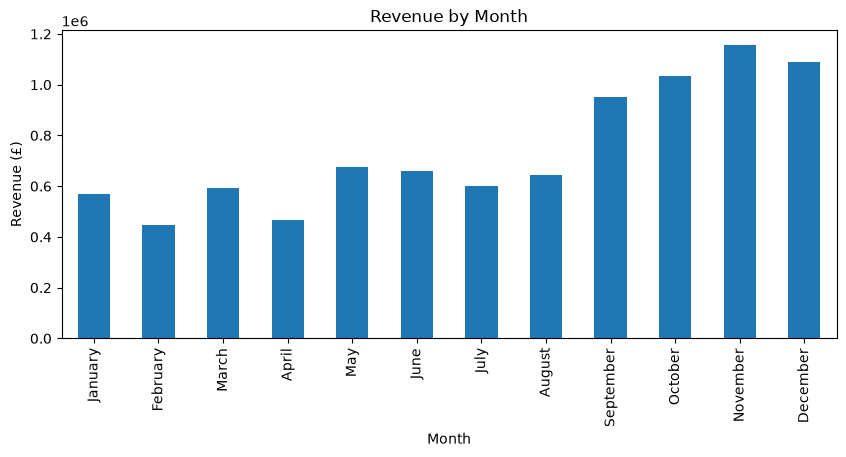

In [43]:
# 3. Revenue by month — check for seasonality (your data spans Dec 2010–Dec 2011)
month_order = ["January","February","March","April","May","June","July",
                "August","September","October","November","December"]
df.groupby("Month")["TotalPrice"].sum().reindex(month_order).plot(kind="bar", figsize=(10,4))
plt.title("Revenue by Month")
plt.ylabel("Revenue (£)")
plt.show()

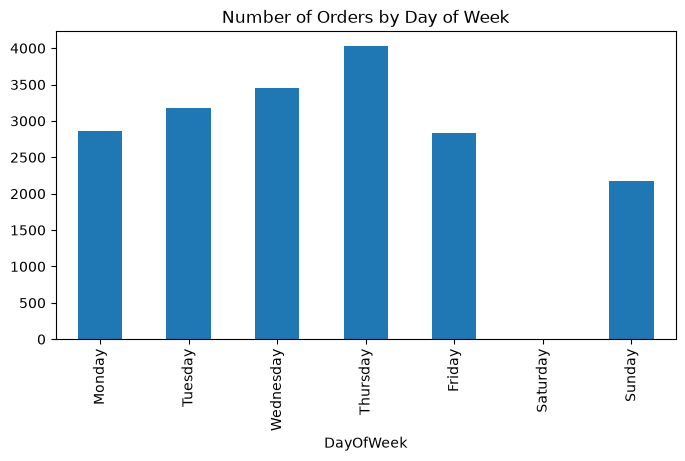

In [44]:
# 4. Number of orders by day of week (frequency, not just £)
df.groupby("DayOfWeek")["InvoiceNo"].nunique().reindex(order).plot(kind="bar", figsize=(8,4))
plt.title("Number of Orders by Day of Week")
plt.show()

In [45]:
print(df.shape)
print(df.isnull().sum())
print(df["Quantity"].min(), df["UnitPrice"].min())

(392692, 9)
InvoiceNo      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
TotalPrice     0
Hour           0
DayOfWeek      0
Month          0
dtype: int64
1 0.001
